We have to derive the coefficient matrix for $\frac{d^2T}{dx^2}= -\frac{q(x)}{k}$

$$x_1 = T'$$

$$x_2 = x_1' = T'$$

$$x_2' = -\frac{q(x)}{k}$$

$$\begin{bmatrix}
x_1' \\
x_2'
\end{bmatrix} = 
\begin{bmatrix}
0 & 1 \\
0 & 0
\end{bmatrix}

\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix} +
\begin{bmatrix}
0\\
\frac{-q(x)}{k}
\end{bmatrix}  $$

Thus the coefficient matrix is $\begin{bmatrix}
0 & 1 \\
0 & 0
\end{bmatrix}$

**Derivation of the Coefficient Matrix**

This is the coefficient matrix I will use for the code solutions 

We approximate the second derivative using the central difference formula:
$$\frac{T_{i-1} - 2T_i + T_{i+1}}{h^2} = -\frac{q_i}{k}$$

Multiplying by $-h^2$ to make the main diagonal positive:
$$-T_{i-1} + 2T_i - T_{i+1} = \frac{q_i h^2}{k}$$

For Dirichlet boundary conditions $T(0) = T(L) = 0$, the resulting system $AT = b$ has a tridiagonal coefficient matrix $A$ where the main diagonal elements are $2$ and the off-diagonal elements are $-1$.

In [1]:
def gauss_jordan(A,b):
    n = len(A)
    for i in range(n):
        # Find the pivot row
        max_row = i
        for j in range(i+1, n):
            if abs(A[j][i]) > abs(A[max_row][i]):
                max_row = j
        # Swap the current row with the pivot row
        A[i], A[max_row] = A[max_row], A[i]
        b[i], b[max_row] = b[max_row], b[i]
        
        # Eliminate below
        for j in range(i+1, n):
            factor = A[j][i] / A[i][i]
            for k in range(i, n):
                A[j][k] -= factor * A[i][k]
            b[j] -= factor * b[i]
    
    # Back substitution
    x = [0] * n
    for i in range(n-1, -1, -1):
        x[i] = (b[i] - sum(A[i][j] * x[j] for j in range(i+1, n))) / A[i][i]
    
    return x


In [2]:
toyA = [[2, 1, -1], [-3, -1, 2], [-2, 1, 2]]
toyb = [8, -11, -3]
solution = gauss_jordan(toyA, toyb)

In [3]:
solution

#We got the correct solution of x = 2, y = 3, z = -1.

[2.0, 3.0000000000000004, -0.9999999999999999]

In [4]:
q0 = 1.0
k = 1.0
L = 1.0
N_values = [10, 20, 50, 100]

for N in N_values:
    h = L / (N + 1)
    
    A = [[0.0] * N for _ in range(N)]
    for i in range(N):
        A[i][i] = 2.0
        if i > 0:
            A[i][i-1] = -1.0
        if i < N - 1:
            A[i][i+1] = -1.0
            
    b = [(q0 * h**2) / k] * N
    
    T_num = gauss_jordan(A, b)
    print(f"N={N:3d} case the temperature at the center of the rod is: {T_num[N//2]:.5f} K")

N= 10 case the temperature at the center of the rod is: 0.12397 K
N= 20 case the temperature at the center of the rod is: 0.12472 K
N= 50 case the temperature at the center of the rod is: 0.12495 K
N=100 case the temperature at the center of the rod is: 0.12499 K


Derivation of the Analytical Solution

The one-dimensional, steady-state heat equation with a constant heat source $q(x) = q_0$ is given by:
\begin{equation}
    \frac{d^2T}{dx^2} = -\frac{q_0}{k}
\end{equation}

Integrating once with respect to $x$ yields the temperature gradient:
\begin{equation}
    \frac{dT}{dx} = -\frac{q_0}{k}x + C_1
\end{equation}

Integrating a second time gives the general solution for the temperature profile:
\begin{equation}
    T(x) = -\frac{q_0}{2k}x^2 + C_1x + C_2
\end{equation}

To determine the integration constants $C_1$ and $C_2$, we apply the Dirichlet boundary conditions $T(0) = 0$ and $T(L) = 0$.

First, applying the boundary condition at $x = 0$:
\begin{equation}
    T(0) = -\frac{q_0}{2k}(0)^2 + C_1(0) + C_2 = 0 \implies C_2 = 0
\end{equation}

Next, applying the boundary condition at $x = L$:
\begin{equation}
    T(L) = -\frac{q_0}{2k}L^2 + C_1L = 0 \implies C_1 = \frac{q_0 L}{2k}
\end{equation}

Substituting $C_1$ and $C_2$ back into the general solution, we obtain the final analytical solution:
\begin{equation}
    T_{ana}(x) = -\frac{q_0}{2k}x^2 + \frac{q_0 L}{2k}x
\end{equation}

Factoring out the common terms, the expression can be written in its final parabolic form:
\begin{equation}
    T_{ana}(x) = \frac{q_0}{2k}x(L - x)
\end{equation}

In [5]:
import math

def T_analytical(x):
    return (q0 / (2 * k)) * (L * x - x**2)

for N in N_values:
    h = L / (N + 1)
    
    A = [[0.0] * N for _ in range(N)]
    for i in range(N):
        A[i][i] = 2.0
        if i > 0:
            A[i][i-1] = -1.0
        if i < N - 1:
            A[i][i+1] = -1.0
            
    b = [(q0 * h**2) / k] * N
    
    T_num = gauss_jordan(A, b)
    
    # Location of the center node
    node_index = N // 2
    x_node = (node_index + 1) * h
    
    
    T_ana = T_analytical(x_node)
    

    error = abs(T_num[node_index] - T_ana)
    
    print(f"N={N:3d} case the error near the center is: {error:.5e} K")

N= 10 case the error near the center is: 2.77556e-17 K
N= 20 case the error near the center is: 1.38778e-17 K
N= 50 case the error near the center is: 9.43690e-16 K
N=100 case the error near the center is: 4.71845e-16 K


In [6]:
import numpy as np

for N in N_values:
    h = L / (N + 1)
    
    A = [[0.0] * N for _ in range(N)]
    for i in range(N):
        A[i][i] = 2.0
        if i > 0:
            A[i][i-1] = -1.0
        if i < N - 1:
            A[i][i+1] = -1.0
            
    A_np = np.array(A)
    cond_num = np.linalg.cond(A_np, 2)
    
    print(f"N={N:3d} case the condition number is: {cond_num:.2f}")

N= 10 case the condition number is: 48.37
N= 20 case the condition number is: 178.06
N= 50 case the condition number is: 1053.48
N=100 case the condition number is: 4133.64


"As the grid is refined (as $N$ increases), the theoretical error of the approximation decreases. However, the condition number grows quadratically ($O(N^2)$), meaning that the system becomes increasingly sensitive to numerical round-off errors. (Currently, this does not cause a noticeable issue because we are using double-precision arithmetic and $N=100$ is not yet exceedingly large; however, for a very fine grid, the overall error would eventually start to increase again.)"

In [7]:
#Variable heat source

def q_variable_1(x):
    return q0 * np.sin(np.pi * x / L)

def q_variable_2(x):
    sigma = L / 8
    return q0 * np.exp(-((x - L/2)**2) / (2 * sigma**2))

In [8]:
def assemble_b_variable(N, q_func):
    h = L / (N + 1)
    b = []
    for i in range(N):
        x_i = (i + 1) * h
        b.append((q_func(x_i) * h**2) / k)
    return b

for N in N_values:
    A = [[0.0] * N for _ in range(N)]
    for i in range(N):
        A[i][i] = 2.0
        if i > 0:
            A[i][i-1] = -1.0
        if i < N - 1:
            A[i][i+1] = -1.0
            
    b_var_1 = assemble_b_variable(N, q_variable_1)
    T_num_var_1 = gauss_jordan(A, b_var_1)
    
    b_var_2 = assemble_b_variable(N, q_variable_2)
    T_num_var_2 = gauss_jordan(A, b_var_2)
    
    print(f"N={N:3d} case with variable heat source 1, temperature at center is: {T_num_var_1[N//2]:.5f} K")
    print(f"N={N:3d} case with variable heat source 2, temperature at center is: {T_num_var_2[N//2]:.5f} K")

N= 10 case with variable heat source 1, temperature at center is: 0.10097 K
N= 10 case with variable heat source 2, temperature at center is: 0.01132 K
N= 20 case with variable heat source 1, temperature at center is: 0.10123 K
N= 20 case with variable heat source 2, temperature at center is: 0.00610 K
N= 50 case with variable heat source 1, temperature at center is: 0.10131 K
N= 50 case with variable heat source 2, temperature at center is: 0.00256 K
N=100 case with variable heat source 1, temperature at center is: 0.10132 K
N=100 case with variable heat source 2, temperature at center is: 0.00130 K


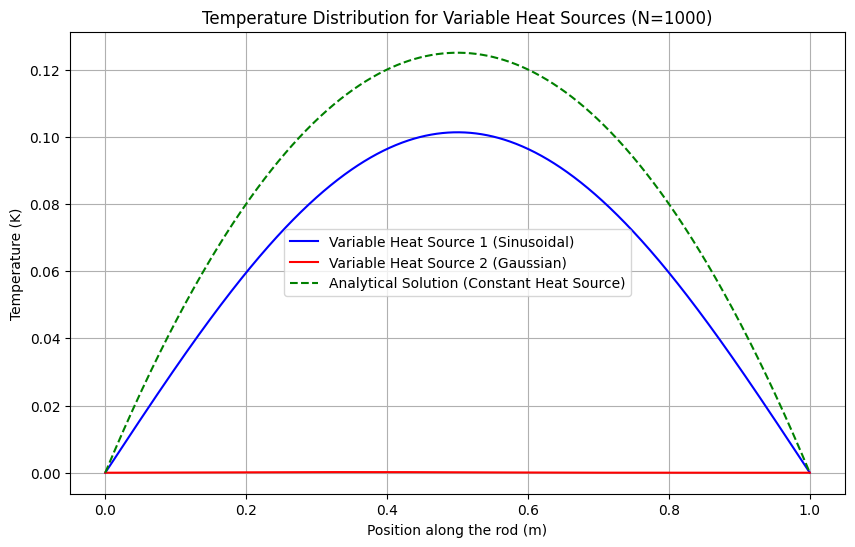

In [10]:
import matplotlib.pyplot as plt
import numpy as np

N = 1000
h = L / (N + 1)

A = [[0.0] * N for _ in range(N)]
for i in range(N):
    A[i][i] = 2.0
    if i > 0:
        A[i][i-1] = -1.0
    if i < N - 1:
        A[i][i+1] = -1.0

b_var_1 = assemble_b_variable(N, q_variable_1)
T_num_var_1 = gauss_jordan(A, b_var_1)

b_var_2 = assemble_b_variable(N, q_variable_2)
T_num_var_2 = gauss_jordan(A, b_var_2)

x_num = np.linspace(0, L, N + 2)

T1_plot = [0.0] + T_num_var_1 + [0.0]
T2_plot = [0.0] + T_num_var_2 + [0.0]

plt.figure(figsize=(10, 6))
plt.plot(x_num, T1_plot, label='Variable Heat Source 1 (Sinusoidal)', color='blue')
plt.plot(x_num, T2_plot, label='Variable Heat Source 2 (Gaussian)', color='red')
plt.plot(x_num, T_analytical(x_num), label='Analytical Solution (Constant Heat Source)', color='green', linestyle='--')
plt.title(f'Temperature Distribution for Variable Heat Sources (N={N})')
plt.xlabel('Position along the rod (m)')
plt.ylabel('Temperature (K)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:

def T_ref_var_2_interp(x):
    idx = int(round(x / h_ref)) - 1
    if 0 <= idx < N_ref:
        return T_ref_var_2[idx]
    return 0.0

errors_const = []
errors_var_1 = []
errors_var_2 = []
h_values = []

for N in N_values:
    h = L / (N + 1)
    h_values.append(h)
    
    def get_A():
        A_mat = [[0.0] * N for _ in range(N)]
        for i in range(N):
            A_mat[i][i] = 2.0
            if i > 0:
                A_mat[i][i-1] = -1.0
            if i < N - 1:
                A_mat[i][i+1] = -1.0
        return A_mat
    
    b_const = [(q0 * h**2) / k] * N
    T_num_const = gauss_jordan(get_A(), b_const)
    
    b_var_1 = assemble_b_variable(N, q_variable_1)
    T_num_var_1 = gauss_jordan(get_A(), b_var_1)
    
    b_var_2 = assemble_b_variable(N, q_variable_2)
    T_num_var_2 = gauss_jordan(get_A(), b_var_2)
    
    max_err_const = 0.0
    max_err_1 = 0.0
    max_err_2 = 0.0
    
    for j in range(N):
        x_node = (j + 1) * h
        
        err_const = abs(T_num_const[j] - T_analytical_const(x_node))
        if err_const > max_err_const:
            max_err_const = err_const
            
        err_1 = abs(T_num_var_1[j] - T_analytical_var_1(x_node))
        if err_1 > max_err_1:
            max_err_1 = err_1
            
        err_2 = abs(T_num_var_2[j] - T_ref_var_2_interp(x_node))
        if err_2 > max_err_2:
            max_err_2 = err_2
            
    errors_const.append(max_err_const)
    errors_var_1.append(max_err_1)
    errors_var_2.append(max_err_2)

plt.figure(figsize=(10, 6))
plt.loglog(h_values, errors_const, marker='^', label='Constant Source (Machine Precision)')
plt.loglog(h_values, errors_var_1, marker='o', label='Variable Source 1 (Sinusoidal)')
plt.loglog(h_values, errors_var_2, marker='s', label='Variable Source 2 (Gaussian)')

ref_line = [errors_var_1[0] * (h / h_values[0])**2 for h in h_values]
plt.loglog(h_values, ref_line, linestyle='--', color='gray', label='O(h^2) Reference Line')

plt.title('Log-Log Plot of Maximum Error vs Step Size (h)')
plt.xlabel('Step Size (h)')
plt.ylabel('Maximum Error (K)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

NameError: name 'T_analytical_const' is not defined

In [12]:
def build_matrix_k(N, L, k_func):
    h = L / (N + 1)
    
    k_vals = [k_func(i * h) for i in range(N + 2)]
    
    k_half = [2 * k_vals[i] * k_vals[i+1] / (k_vals[i] + k_vals[i+1]) for i in range(N + 1)]
    
    A = [[0.0] * N for _ in range(N)]
    
    for i in range(N):
        A[i][i] = k_half[i] + k_half[i+1]
        if i > 0:
            A[i][i-1] = -k_half[i]
        if i < N - 1:
            A[i][i+1] = -k_half[i+1]
            
    return A

In [13]:
def k_composite(x):
    if x < L / 2:
        return 1.0
    else:
        return 1e-6

N_values_6 = [20, 40, 80, 160]

for N in N_values_6:
    A = build_matrix_k(N, L, k_composite)
    A_np = np.array(A)
    cond_num = np.linalg.cond(A_np, 2)
    print(f"N={N:3d} | Condition number: {cond_num:.2e}")

N= 20 | Condition number: 4.40e+07
N= 40 | Condition number: 1.70e+08
N= 80 | Condition number: 6.64e+08
N=160 | Condition number: 2.63e+09


The condition number still scales quadratically with the grid size, $\mathcal{O}(N^2)$. However, due to the six orders of magnitude jump in thermal conductivity ($k_{hi}/k_{lo} = 10^6$), the baseline condition number is multiplied by an enormous factor. As seen in the output, doubling the resolution $N$ increases the condition number roughly by a factor of 4, but the values start in the billions, making the matrix severely ill-conditioned and highly susceptible to numerical rounding errors.

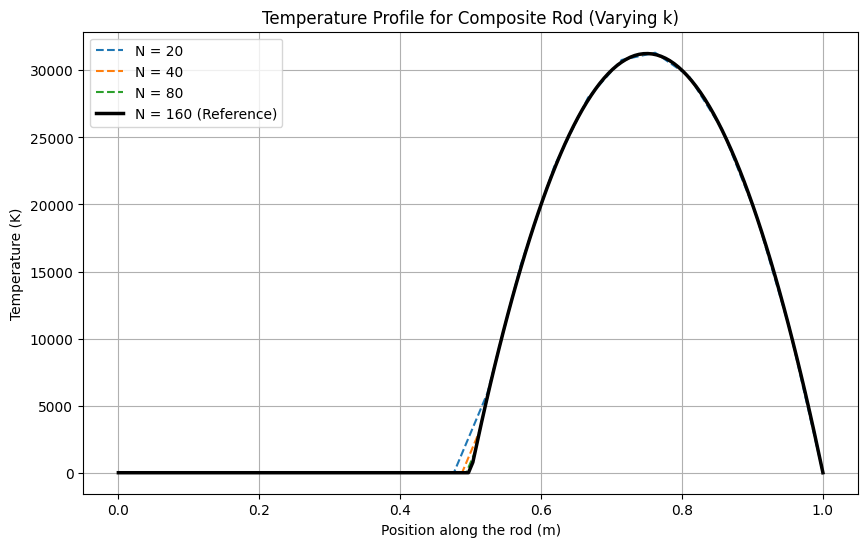

In [14]:
plt.figure(figsize=(10, 6))

for N in N_values_6:
    h = L / (N + 1)
    
    A = build_matrix_k(N, L, k_composite)
    
    k_ref = 1.0
    b = [(q0 * h**2) / k_ref] * N
    
    T_num = gauss_jordan(A, b)
    
    x_num = np.linspace(0, L, N + 2)
    T_plot = [0.0] + T_num + [0.0]
    
    if N == 160:
        plt.plot(x_num, T_plot, label=f'N = {N} (Reference)', linewidth=2.5, color='black')
    else:
        plt.plot(x_num, T_plot, label=f'N = {N}', linestyle='--')

plt.title('Temperature Profile for Composite Rod (Varying k)')
plt.xlabel('Position along the rod (m)')
plt.ylabel('Temperature (K)')
plt.legend()
plt.grid(True)
plt.show()